# ___Updating the mycorrhizal states___
--------------------

In [1]:
!python --version

Python 3.13.11


The system cannot find the path specified.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#--------------------------
# CONSTANTS
#--------------------------

COLLABORATION_AXES = [ "F00679", "F00727" ]

PLANT_TAXONOMY_ACCEPTED_COLUMNS = [ "F01286", "F01287", "F01289", "F01290" ]

STATE_REPLACEMENTS_TRY = { # THIS IS SPECIFICALLY FOR TRY
    "ECTO": "EcM",
    "Ecto": "EcM",
    "EC": "EcM",
    "ectomycorrhiza": "EcM",
    "Ectomycorrhiza": "EcM",
    "ecto": "EM",
    "ectomycorrhizal": "EcM",
    "ECM": "EcM",
    "vesicular-arbuscular mycorrhiza" : "AM",
    "VAM": "AM",
    "VA": "AM",
    "Non": "NM",
    "AMNM": "NM/AM",
    "Ericoid": "ErM",
    "ERM": "ErM",
    "AM + EM": "AM/EcM",
    "EC/AM": "AM/EcM",
    "Orchid": "OrM",
    "OrM": "OrM"
}

STATE_REPLACEMENTS = { # THIS IS FOR FRED
    "AM + EM": "AM/EcM",
    "AM + EM + NM": "AM/EcM/NM",
    "AM + NM": "AM/NM",
    "AM AM + EM": "AM/EcM",
    "AM AM + EM + NM": "AM/EcM/NM",
    "AM AM + NM": "AM/NM",
    "AM+EM": "AM/EcM",
    "AM+NM": "AM/NM",
    "EM": "EcM",
    "EM AM": "AM/EcM",
    "EM AM + EM + NM": "AM/EcM/NM",
    "EM EM + EEM + NM": "EcM/NM",
    "EM EM+AM": "AM/EcM",
    "ERM": "ErM",
    "EcM-AM": "AM/EcM",
    "NM AM + NM": "AM/NM",
    "NM-AM": "AM/NM",
    "NM/AM": "AM/NM",
}

In [4]:
# https://datadryad.org/dataset/doi:10.5061/dryad.n8bm9
# THE SHEET "Original states data" HAS THE RAW DATA SCRAPED FROM PUBLICATIONS WITHOUT ANY INTEFERENCE FROM THE AUTHORS!!!!
maherali_original = pd.read_excel(r"../../data/chapter2/Maherali.etal.AmNat.Data.xlsx", sheet_name="Original states data", skiprows=range(2),
                                  usecols=("Source", "Original name (Genus species)", "Raw state record from publication"))
maherali_original.rename(mapper={old: old.replace('(', '').replace(')', '').lower().replace(' ', '_') for old in maherali_original.columns}, axis=1, inplace=True) # column names have parentheses and spaces
# taxonomy columns in Maherali et. al. dataset has trailing spaces :(
maherali_original.loc[:, "original_name_genus_species"] = maherali_original.original_name_genus_species.str.strip()
maherali_original.loc[:, "raw_state_record_from_publication"] = maherali_original.raw_state_record_from_publication.str.strip()
maherali_original.drop_duplicates(subset=("original_name_genus_species", "raw_state_record_from_publication"), inplace=True)

# final_maherali = pd.read_excel(r"../../data/chapter2/Maherali.etal.AmNat.Data.xlsx", sheet_name="Final list matched with phylo", skiprows=range(2))
# final_maherali.rename(mapper={old: old.lower().replace(' ', '_') for old in final_maherali.columns}, axis=1, inplace=True)
# final_maherali.genus_species = final_maherali.genus_species.str.strip().str.replace('_', ' ') # the sheet "Final list matched with phylo" has genus and specific epithets concatenated by under scores!

# in TRY, mycorrhiza type is trait id 7
try_myco = pd.read_csv(r"../../data/chapter2/TRY/mycorrhizal_states.txt", delimiter='\t', low_memory=False, encoding="latin1", usecols=["Dataset", "SpeciesName", "AccSpeciesName", "OrigValueStr",
                                "TraitID"]).dropna(subset=["AccSpeciesName", "OrigValueStr", "TraitID"])
# unify the mycorrhizal state info
# 'ECTO', 'NM/AM', 'EC', 'EC/AM', 'AM', 'Ecto', 'Non',        'vesicular-arbuscular mycorrhiza', 'ectomycorrhiza', 'no', '0', 'Ph.th.end.', 'VAM', 'Ectomycorrhiza', 'E.ch.ect.', 'arbuscular',
# 'ec?', 'VA', 'ecto', 'Absent', 'non-ectomycorrhizal', 'ectomycorrhizal', 'Yes', 'No', 'EM', 'AMNM', 'NM', 'AM + EM', 'ERM', 'Ericoid', 'ECM'

try_myco.loc[:, "OrigValueStr"] = try_myco.OrigValueStr.replace(STATE_REPLACEMENTS_TRY)
try_myco = try_myco.query("OrigValueStr.isin(@STATE_REPLACEMENTS_TRY.values())")

# scrape the online only MycoDB metadata and serialize it to the disk
# req = Request(url=r"https://www.nature.com/articles/sdata201628/tables/2", headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:142.0) Gecko/20100101 Firefox/142.0"})
# with urlopen(req) as r:
#     soup = BeautifulSoup(r.read())
# 
# table = soup.find(name="table", attrs={"class": "data last-table"}) # locate the metadata table
# [th.text.strip() for th in table.find_all(name="th")] # column names
# mycodb_descriptions = [[td.text for td in tr.find_all(name="td")] for tr in table.find_all(name="tr")[1:]] # parse the rows
# 
# # create a dataframe using the parsed rows and column names and serialize it to the disk
# pd.DataFrame({ 
#     "Variable": [row[0] for row in mycodb_descriptions],
#     "Description": [row[1] for row in mycodb_descriptions],
#     "Variable Type (range)": [row[2] for row in mycodb_descriptions],
#     "Levels (#studies/level)": [row[3] for row in mycodb_descriptions],
# }).to_csv(r"../data/chapter2/MycoDB_version4_metadata.csv", index=False)

# species that have info in FRED v3 for first order fine root traits RD and SRL
collab_categorical = pd.read_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_collab_categorical.csv", usecols=["binominal", "F00004", "F00645"])

# even though we had missing data for photosynthetic pathways and mycorrhizal states in the records that had data for the 4 chosen traits in FRED, FRED could still have info for the categorical traits in other records 
# that were filtered out due to not having all the 4 trait values?????
fred_myco = pd.read_csv(r"../../data/chapter2/FRED/FRED3_Entire_Database_2021.csv", low_memory=False, header=0, skiprows=range(1, 10), encoding="latin1",
                        usecols=("F01286", "F01287", "F00645", "F00004")).dropna(subset=("F01286", "F01287", "F00645")).drop_duplicates()
# concatenate the genus name and specific epithet to introduce a column for binominal name
fred_myco.insert(loc=0, column="binominal", value=fred_myco.F01286.str.strip().str.capitalize() + ' ' + fred_myco.F01287.str.strip().str.lower())

groot_myco = pd.read_csv(r"../../data/chapter2/GRooTFullVersion.csv", low_memory=False, encoding="latin1").query(r"not mycorrhizalAssociationType.isna()").loc[:, ["references", "referencesDataset",
            "genus", "species", "mycorrhizalAssociationType"]].drop_duplicates().dropna(subset=["genus", "species"]).apply(lambda _: _.str.strip(), axis=0)
groot_myco.insert(loc=0, column="binominal", value=groot_myco.genus + ' ' + groot_myco.species)
# even though GRoot has a column for mycorrhizal types directly extracted from FungalRoot (mycorrhizalAssociationTypeFungalRoot), we ignore this because we'll also look through FungalRoot to populate missing values,
# so .....

FileNotFoundError: [Errno 2] No such file or directory: '../../data/chapter2/FREDv3subset/FRED_subset_collab_categorical.csv'

In [15]:
species_of_interest = collab_categorical.binominal.unique() # loc[:, ["F01286", "F01287"]].drop_duplicates().agg(' '.join, axis=1).str.strip().reset_index(drop=True)
species_of_interest.size # we have 395 species for which we have first order root trait values for SRL and RD :)

395

In [48]:
#------------------------------------------------------------------------------------------
# THE GOAL HERE IS TO FIND THE CORRECT MYCORRHIZAL STATE DATA FOR THESE 395 SPECIES
#------------------------------------------------------------------------------------------

### ___Maherali, H. et al. (2016)___
------------------------------

In [11]:
maherali_original_ = maherali_original.query("original_name_genus_species.isin(@species_of_interest)").drop_duplicates(subset=["original_name_genus_species", "raw_state_record_from_publication"])
maherali_original_

,source,original_name_genus_species,raw_state_record_from_publication
29,Akhmetzhanova et al. 2012,Abies nephrolepis,EM
70,Wang&Qiu2006,Acacia auriculiformis,AM
80,Wang&Qiu2006,Acacia mangium,EM AM
99,Akhmetzhanova et al. 2012,Acer barbinerve,EM
108,Akhmetzhanova et al. 2012,Acer davidii,AM
...,...,...,...
11958,Akhmetzhanova et al. 2012,Ulmus pumila,NM
11985,Wang&Qiu2006,Vaccinium corymbosum,ERM
12240,Akhmetzhanova et al. 2012,Veronica spuria,AM
12444,Wang&Qiu2006,Vitis vinifera,AM


### ___TRY___
--------------------

In [12]:
try_myco_ = try_myco.query("AccSpeciesName.isin(@species_of_interest)").drop_duplicates(subset=["AccSpeciesName", "OrigValueStr"])
try_myco_

,Dataset,SpeciesName,AccSpeciesName,TraitID,OrigValueStr
7,Abisko & Sheffield Database,Caltha palustris,Caltha palustris,7.0,NM/AM
18,Abisko & Sheffield Database,Pinus sylvestris,Pinus sylvestris,7.0,EcM
20,Abisko & Sheffield Database,Populus tremula,Populus tremula,7.0,EcM
33,Abisko & Sheffield Database,Sorbus aucuparia,Sorbus aucuparia,7.0,NM/AM
49,Sheffield Database,Quercus robur,Quercus robur,7.0,EcM
...,...,...,...,...,...
1143409,Independent evolutionary changes in fine-root ...,Castanea henryi,Castanea henryi,7.0,EcM
1143433,Independent evolutionary changes in fine-root ...,Castanopsis wattii,Castanopsis wattii,7.0,EcM
1143481,Independent evolutionary changes in fine-root ...,Lithocarpus chiungchungensis,Lithocarpus chiungchungensis,7.0,EcM
1143583,Independent evolutionary changes in fine-root ...,Quercus serrata,Quercus serrata,7.0,EcM


### ___FRED___
-------------------------------

In [13]:
# again, since this is FRED, look only for species that we do not have mycorrhizal state info for in the subset
missing_states_collab_species = collab_categorical.query("F00645.isna()").loc[:, ["F01286", "F01287"]].drop_duplicates().agg(' '.join, axis=1).str.strip().reset_index(drop=True)
missing_states_collab_species

0             Acer saccharum
1         Fraxinus americana
2            Viola pubescens
3     Hydrophyllum canadense
4             Larix gmelinii
               ...          
91           Ulmus americana
92        Betula platyphylla
93           Malus domestica
94            Prunus persica
95            Vitis vinifera
Length: 96, dtype: object

In [14]:
# some of the records just have "mycorrhizal" for the F00645 column, we do not want that!!!
fred_myco_ = fred_myco.query("binominal.isin(@missing_states_collab_species) and (F00645!='mycorrhizal')").drop_duplicates(subset=["binominal", "F00645"])
fred_myco_

,binominal,F00004,F01286,F01287,F00645
0,Dicranopteris linearis,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Dicranopteris,linearis,AM
3,Cunninghamia lanceolata,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Cunninghamia,lanceolata,AM
6,Magnolia baillonii,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Magnolia,baillonii,AM
11,Acacia auriculiformis,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Acacia,auriculiformis,AM
15,Gordonia axillaris,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",Gordonia,axillaris,AM
...,...,...,...,...,...
53506,Vitis vinifera,"Akhmetzhanova AA, Soudzilovskaiana NA, Onipche...",Vitis,vinifera,AM
54225,Acer pictum,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",Acer,pictum,AM
54266,Castanopsis faberi,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",Castanopsis,faberi,EM
54281,Elaeocarpus sylvestris,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",Elaeocarpus,sylvestris,AM


### ___GRoot___
----------------------------

In [15]:
groot_myco_ = groot_myco.query("binominal.isin(@species_of_interest)").drop_duplicates(subset=["binominal", "mycorrhizalAssociationType"])
groot_myco_

,binominal,references,referencesDataset,genus,species,mycorrhizalAssociationType
245,Acer negundo,"Adams TS, McCormack ML, Eissenstat DM. 2013. F...",NaN,Acer,negundo,AM
260,Liriodendron tulipifera,"Adams TS, McCormack ML, Eissenstat DM. 2013. F...",NaN,Liriodendron,tulipifera,AM
275,Populus tremuloides,"Adams TS, McCormack ML, Eissenstat DM. 2013. F...",NaN,Populus,tremuloides,AM
3310,Acer davidii,"Chen W, Zeng H, Eissenstat DM, Guo D. 2013. Va...",NaN,Acer,davidii,AM
3334,Acer truncatum,"Chen W, Zeng H, Eissenstat DM, Guo D. 2013. Va...",NaN,Acer,truncatum,EcM-AM
...,...,...,...,...,...,...
87258,Salix viminalis,"Asem A. Akhmetzhanova, Nadejda A. Soudzilovska...",162_Mycorrhizal Intensity Database Across the ...,Salix,viminalis,EcM
87412,Sorbus aucuparia,"Asem A. Akhmetzhanova, Nadejda A. Soudzilovska...",162_Mycorrhizal Intensity Database Across the ...,Sorbus,aucuparia,AM
89241,Crataegus pinnatifida,"Asem A. Akhmetzhanova, Nadejda A. Soudzilovska...",162_Mycorrhizal Intensity Database Across the ...,Crataegus,pinnatifida,AM
89424,Pinus edulis,"Asem A. Akhmetzhanova, Nadejda A. Soudzilovska...",162_Mycorrhizal Intensity Database Across the ...,Pinus,edulis,EcM


In [16]:
#-----------------------------------------------------------
# NOW COMBINE ALL OF THESE TO CREATE A SINGLE DATASET
#-----------------------------------------------------------

In [17]:
data = pd.merge(left=maherali_original_.rename({"original_name_genus_species": "binominal"}, axis=1), left_on="binominal",
         right=try_myco_.rename({"AccSpeciesName": "binominal"}, axis=1), right_on="binominal", how="outer").drop(["SpeciesName", "TraitID"], axis=1)
data

,source,binominal,raw_state_record_from_publication,Dataset,OrigValueStr
0,Akhmetzhanova et al. 2012,Abies nephrolepis,EM,Mycorrhizal Intensity Database Across the Form...,EcM
1,Akhmetzhanova et al. 2012,Abies nephrolepis,EM,FRED - Fine Root Ecology Database,EM
2,Wang&Qiu2006,Acacia auriculiformis,AM,Global 15N Database,AM
3,Wang&Qiu2006,Acacia auriculiformis,AM,Mycorrhiza Database,EcM
4,NaN,Acacia crassicarpa,NaN,FRED - Fine Root Ecology Database,AM/EcM
...,...,...,...,...,...
544,Wang&Qiu2006,Vaccinium corymbosum,ERM,Independent evolutionary changes in fine-root ...,ErM
545,NaN,Vaccinium mandarinorum,NaN,FRED - Fine Root Ecology Database,ErM
546,Akhmetzhanova et al. 2012,Veronica spuria,AM,Mycorrhizal Intensity Database Across the Form...,AM
547,Wang&Qiu2006,Vitis vinifera,AM,FRED - Fine Root Ecology Database,AM


In [18]:
data = pd.merge(left=data, left_on="binominal", right=fred_myco_, right_on="binominal", how="outer").drop(["F01286", "F01287"], axis=1)
data

,source,binominal,raw_state_record_from_publication,Dataset,OrigValueStr,F00004,F00645
0,Akhmetzhanova et al. 2012,Abies nephrolepis,EM,Mycorrhizal Intensity Database Across the Form...,EcM,NaN,NaN
1,Akhmetzhanova et al. 2012,Abies nephrolepis,EM,FRED - Fine Root Ecology Database,EM,NaN,NaN
2,Wang&Qiu2006,Acacia auriculiformis,AM,Global 15N Database,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",AM
3,Wang&Qiu2006,Acacia auriculiformis,AM,Mycorrhiza Database,EcM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",AM
4,NaN,Acacia crassicarpa,NaN,FRED - Fine Root Ecology Database,AM/EcM,NaN,NaN
...,...,...,...,...,...,...,...
576,Wang&Qiu2006,Vaccinium corymbosum,ERM,Independent evolutionary changes in fine-root ...,ErM,NaN,NaN
577,NaN,Vaccinium mandarinorum,NaN,FRED - Fine Root Ecology Database,ErM,NaN,NaN
578,Akhmetzhanova et al. 2012,Veronica spuria,AM,Mycorrhizal Intensity Database Across the Form...,AM,NaN,NaN
579,Wang&Qiu2006,Vitis vinifera,AM,FRED - Fine Root Ecology Database,AM,"Akhmetzhanova AA, Soudzilovskaiana NA, Onipche...",AM


In [19]:
data = pd.merge(left=data, left_on="binominal", right=groot_myco_, right_on="binominal", how="outer").drop(["genus", "species"], axis=1)
data

,source,binominal,raw_state_record_from_publication,Dataset,OrigValueStr,F00004,F00645,references,referencesDataset,mycorrhizalAssociationType
0,NaN,Abelia biflora,NaN,NaN,NaN,NaN,NaN,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",NaN,AM
1,Akhmetzhanova et al. 2012,Abies nephrolepis,EM,Mycorrhizal Intensity Database Across the Form...,EcM,NaN,NaN,"Dong L, Mao Z, Sun T. 2016. Condensed tannin e...",NaN,EcM
2,Akhmetzhanova et al. 2012,Abies nephrolepis,EM,FRED - Fine Root Ecology Database,EM,NaN,NaN,"Dong L, Mao Z, Sun T. 2016. Condensed tannin e...",NaN,EcM
3,Wang&Qiu2006,Acacia auriculiformis,AM,Global 15N Database,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",AM,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",NaN,AM
4,Wang&Qiu2006,Acacia auriculiformis,AM,Mycorrhiza Database,EcM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",AM,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",NaN,AM
...,...,...,...,...,...,...,...,...,...,...
866,NaN,Veratrum nigrum,NaN,NaN,NaN,NaN,NaN,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",NaN,AM
867,Akhmetzhanova et al. 2012,Veronica spuria,AM,Mycorrhizal Intensity Database Across the Form...,AM,NaN,NaN,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",NaN,AM
868,NaN,Vitis amurensis,NaN,NaN,NaN,NaN,NaN,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",NaN,AM
869,Wang&Qiu2006,Vitis vinifera,AM,FRED - Fine Root Ecology Database,AM,"Akhmetzhanova AA, Soudzilovskaiana NA, Onipche...",AM,NaN,NaN,NaN


In [43]:
# in this 
# source, binominal & raw_state_record_from_publication ARE FROM MAHERALI AT AL
# Dataset, OrigValueStr ARE FROM TRY
# F00004, F00645 ARE FROM FRED V3
# references, referencesDataset & mycorrhizalAssociationType ARE FROM GRoot

In [44]:
# now serialize this :)
# NOTE THAT THIS DOES NOT INCLUDE FUNGALROOT - WHICH IS MESSY AND REQUIRES MANUAL DATA EXTRACTION
data.to_csv(r"../../data/chapter2/FREDv3subset/states_to_fill_FRED_TRY_Maherali_GRoot.csv", index=False)

## ___Conflict resolution & population___
----------------------

In [49]:
collab_categorical = pd.read_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_collab_categorical.csv", usecols=["binominal", "F00004", "F00645"])
lookup = pd.read_csv(r"../../data/chapter2/FREDv3subset/unified_states_to_fill_FRED_TRY_Maherali_GRoot.csv") # the curated compilation dataset with standardized mycorrhizal state encodings

In [50]:
collab_categorical.loc[:, "F00645"] = collab_categorical.F00645.replace(STATE_REPLACEMENTS) # resolve the state encoding heterogeneity before duplicate removal
collab_categorical = collab_categorical.drop_duplicates(subset=["binominal", "F00645"]) # remove duplicates
collab_categorical # 456 RECORDS WITH 395 SPECIES

,binominal,F00004,F00645
0,Acer saccharum,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",NaN
1,Fraxinus americana,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",NaN
2,Viola pubescens,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",NaN
3,Hydrophyllum canadense,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",NaN
4,Larix gmelinii,"Wang Z, Guo D, Wang X, Gu J, Mei L. 2006. Fine...",NaN
...,...,...,...
535,Castanopsis carlesii,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",EcM
539,Betula platyphylla,"Wang Y, Gao G, Wang N, Wang Z, Gu J. 2019. Eff...",NaN
544,Malus domestica,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",NaN
545,Prunus persica,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",NaN


In [51]:
collab_categorical[collab_categorical.binominal.duplicated(keep=False)].sort_values("binominal") # we do have records with NaNs in column F00645 here!!!

,binominal,F00004,F00645
188,Acacia auriculiformis,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",AM
274,Acacia auriculiformis,"Kong DL, Wang JJ, Kardol P, Wu HF, Zeng H, Den...",NaN
20,Acer caudatum,"Shi W, Wang ZQ, Liu JL, Gu JC, Guo DL. 2008. F...",EcM
468,Acer caudatum,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
404,Acer pictum,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
...,...,...,...
248,Tilia mandshurica,"Chen W, Zeng H, Eissenstat DM, Guo D. 2013. Va...",AM
84,Ulmus americana,"Valverde-Barrantes OJ, Smemo KA, Blackwood CB...",AM
354,Ulmus americana,Valverde et al (unpublished),NaN
27,Ulmus davidiana,"Shi W, Wang ZQ, Liu JL, Gu JC, Guo DL. 2008. F...",EcM


In [52]:
collab_categorical_nan_dups = collab_categorical[collab_categorical.binominal.duplicated(keep=False)].query(r"F00645.isna()").index # duplicated species names where the duplication happens with NaNs in the state column
collab_categorical_nan_dups

Index([  0,   1,   4,   5,  31,  32,  33,  35,  37,  42,  43,  44, 202, 205,
       207, 274, 275, 276, 277, 286, 287, 293, 298, 302, 308, 309, 322, 323,
       324, 325, 326, 327, 328, 329, 331, 332, 333, 334, 336, 337, 339, 340,
       341, 342, 343, 344, 345, 346, 349, 350, 352, 353, 354, 539],
      dtype='int64')

In [53]:
assert collab_categorical.loc[collab_categorical_nan_dups, "F00645"].isna().mean() == 1.000 # cool

In [54]:
 # get rid of the NaN duplicates
collab_categorical = collab_categorical.drop(index=collab_categorical_nan_dups).sort_values(by="binominal").reset_index(drop=True)
collab_categorical # 402 records with 395 species, not bad

,binominal,F00004,F00645
0,Abelia biflora,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
1,Abies fargesii,"Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fine...",NaN
2,Abies nephrolepis,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",EcM
3,Acacia auriculiformis,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",AM
4,Acacia crassicarpa,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",AM/EcM
...,...,...,...
397,Veronica spuria,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
398,Viola pubescens,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",NaN
399,Vitis amurensis,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
400,Vitis vinifera,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",NaN


In [55]:
assert collab_categorical.binominal.unique().size == 395

In [56]:
# this must be executed after the removal of the NaN duplicates!!!!!!!
collab_categorical[collab_categorical.binominal.duplicated(keep=False)] # CONFLICTS WITHIN THE ORIGINAL FRED SUBSET!!!!
# this needs to be resolved

,binominal,F00004,F00645
8,Acer caudatum,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
9,Acer caudatum,"Shi W, Wang ZQ, Liu JL, Gu JC, Guo DL. 2008. F...",EcM
14,Acer pictum,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
15,Acer pictum,"Shi W, Wang ZQ, Liu JL, Gu JC, Guo DL. 2008. F...",EcM
20,Acer tataricum,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
21,Acer tataricum,"Shi W, Wang ZQ, Liu JL, Gu JC, Guo DL. 2008. F...",EcM
29,Adiantum pedatum,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",mycorrhizal
30,Adiantum pedatum,"Dong X, Wang H, Gu J, Wang Y, Wang Z. 2014. Ro...",AM
372,Syringa reticulata,"Valverde-Barrantes OJ, Smemo KA, Blackwood CB...",AM
373,Syringa reticulata,"Chen W, Zeng H, Eissenstat DM, Guo D. 2013. Va...",AM/EcM


In [57]:
#------------------------------------------------------------------------------------------------------------------------------------
# REMEMBER THAT WE CANNOT JUST DROP THE RECORDS WITHOUT STATE INFO BECAUSE WE HAVE THE ROOT TRAIT INFO FOR THOSE SPECIES
#------------------------------------------------------------------------------------------------------------------------------------

In [58]:
merged = pd.merge(left=collab_categorical, left_on="binominal", right=lookup, right_on="binominal", how="left", suffixes=('_', None)) # postfixing the columns from our subset with an underscore
merged.sort_values(by="binominal", inplace=True)

In [59]:
merged

,binominal,F00004_,F00645_,source,raw_state_record_from_publication,Dataset,OrigValueStr,F00004,F00645,references,referencesDataset,mycorrhizalAssociationType
0,Abelia biflora,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM,NaN,NaN,NaN,NaN,NaN,NaN,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",NaN,AM
1,Abies fargesii,"Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fine...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abies nephrolepis,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",EcM,Akhmetzhanova et al. 2012,EcM,Mycorrhizal Intensity Database Across the Form...,EcM,NaN,NaN,"Dong L, Mao Z, Sun T. 2016. Condensed tannin e...",NaN,EcM
3,Abies nephrolepis,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",EcM,Akhmetzhanova et al. 2012,EcM,FRED - Fine Root Ecology Database,EcM,NaN,NaN,"Dong L, Mao Z, Sun T. 2016. Condensed tannin e...",NaN,EcM
4,Acacia auriculiformis,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",AM,Wang&Qiu2006,AM,Global 15N Database,AM,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",AM,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",NaN,AM
...,...,...,...,...,...,...,...,...,...,...,...,...
922,Veronica spuria,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM,Akhmetzhanova et al. 2012,AM,Mycorrhizal Intensity Database Across the Form...,AM,NaN,NaN,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",NaN,AM
923,Viola pubescens,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
924,Vitis amurensis,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM,NaN,NaN,NaN,NaN,NaN,NaN,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",NaN,AM
925,Vitis vinifera,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",NaN,Wang&Qiu2006,AM,FRED - Fine Root Ecology Database,AM,"Akhmetzhanova AA, Soudzilovskaiana NA, Onipche...",AM,NaN,NaN,NaN


In [60]:
assert all(np.sort(merged.binominal.unique()) == np.sort(collab_categorical.binominal.unique())) # good :)

In [61]:
STATE_COLUMNS = ["F00645_", "F00645", "raw_state_record_from_publication", "OrigValueStr", "mycorrhizalAssociationType"] # F00645_ is the column from the FRED subset we have root trait info for

In [39]:
#---------------------------------------------------------------------------------------------------------
# BEFORE CHECKING FOR CONFLICTS, MAKE SURE ALL THE STATE ENCODINGS ARE IN A UNIFIED FORMAT
#---------------------------------------------------------------------------------------------------------

In [62]:
merged.loc[:, STATE_COLUMNS].apply(lambda _: _.dropna().unique()) # HEAPS OF VARIATION IN THE ENCODING

F00645_                                 [AM, EcM, AM/EcM, AM/NM, mycorrhizal, NM, ErM]
F00645                                                           [AM, NM, EcM, AM/EcM]
raw_state_record_from_publication    [EcM, AM, AM/EcM, NM, AM/EcM/NM, AM/NM, EcM/NM...
OrigValueStr                                         [EcM, AM, AM/EcM, AM/NM, NM, ErM]
mycorrhizalAssociationType                           [AM, EcM, AM/EcM, NM, AM/NM, ErM]
dtype: object

In [63]:
np.unique(np.concatenate(merged.loc[:, STATE_COLUMNS + ["F00645_"]].apply(lambda _: _.dropna().unique()).values))

array(['AM', 'AM/EcM', 'AM/EcM/NM', 'AM/NM', 'EcM', 'EcM/NM', 'ErM', 'NM',
       'mycorrhizal'], dtype=object)

In [42]:
# merged.loc[:, STATE_COLUMNS] = merged.loc[:, STATE_COLUMNS].apply(lambda col: col.replace(STATE_REPLACEMENTS)) # apply the replacements
# this is not necessary now as we are reading in the lookup with standardized mycorrhizal state encodings

In [64]:
#--------------------------
# LOOK FOR CONFLICTS 
#--------------------------

In [65]:
# every species that has more than one mycorrhizal state encoding after stripping away NaNs will need manual intervention!! - as simple as that
# and also the species that do not have any data in all the state columns

In [176]:
all_states_combined = dict.fromkeys(merged.binominal.unique())

for (sp, df) in merged.groupby("binominal"):
    all_states_combined[sp] = pd.Series(df[STATE_COLUMNS].to_numpy().ravel()).dropna().unique() # for each species combine all the state info (including multiple rows) into a signle array, drop the NaNs
    # get the unique values

In [182]:
state_conflict_species = np.array([sp for sp in all_states_combined if all_states_combined[sp].size > 1]) # more than one state encoding
all_nan_species = np.array([sp for sp in all_states_combined if all_states_combined[sp].size == 0]) # no state info whatsoever

In [224]:
clean_records = np.array([(sp, all_states_combined[sp][0]) for sp in all_states_combined if (all_states_combined[sp].size == 1) and (all_states_combined[sp][0] != "mycorrhizal")]) # exactly one state encoding
clean_records.shape # 294 species

(294, 2)

In [187]:
#------------------------------------------------------------------------------------------------------------------------
# LOOKS LIKE SOME RECORDS JUST SAY "MYCORRHIZAL", REMOVE THESE SPECIES AND ADD THEM TO THE MISSING STATE GROUP
#------------------------------------------------------------------------------------------------------------------------

In [196]:
says_just_mycorrhizal = np.array([sp for sp in all_states_combined if "mycorrhizal" in all_states_combined[sp]])
says_just_mycorrhizal.size # 10 species

10

In [203]:
all_state_conflicts = np.unique(np.concat([state_conflict_species, all_nan_species, says_just_mycorrhizal]))
all_state_conflicts.size

101

In [204]:
# resolve the above conflicts using FungalRoot, manually
np.savetxt(fname=r"../../data/chapter2/FREDv3subset/species_missing_and_conflciting_states.csv", X=all_state_conflicts, delimiter=',', fmt=r"%s")

In [225]:
# serialize the good portion too
np.savetxt(fname=r"../../data/chapter2/FREDv3subset/species_clean_states.csv", X=clean_records, delimiter=',', fmt=r"%s")

In [115]:
#--------------------------------------------------------------
# 101 unique problematic species =>
# 81 with conflicting state information
# 13 with no state information whatsoever
# 10 species that just say "mycorrhizal"
#--------------------------------------------------------------

# ___Post-population analyses___
---------------------------

In [255]:
assert collab_categorical.binominal.unique().size == 395
hand_extracted = pd.read_csv(r"../../data/chapter2/FREDv3subset/state_conflicts_resolved.csv")
clean_records = pd.read_csv(r"../../data/chapter2/FREDv3subset/species_clean_states.csv", header=None).rename({0: "binominal", 1: "state"}, axis=1)

In [267]:
clean_records

,binominal,state
0,Abelia biflora,AM
1,Abies nephrolepis,EcM
2,Acer campbellii,AM
3,Acer coriaceifolium,AM
4,Acer davidii,AM
...,...,...
289,Veratrum nigrum,AM
290,Veronica spuria,AM
291,Vitis amurensis,AM
292,Vitis vinifera,AM


In [257]:
hand_extracted

,binominal,actual_publication_reports_in_fungalroot,fungalroot_agreed_species_state,genus_generalized
0,Abies fargesii,EcM,EcM,NaN
1,Acacia auriculiformis,AM/EcM,AM/EcM,NaN
2,Acacia crassicarpa,AM/EcM,AM/EcM,NaN
3,Acacia mangium,AM/EcM,AM/EcM,NaN
4,Acer barbinerve,EcM,AM,NaN
...,...,...,...,...
96,Ulmus davidiana,AM,AM,NaN
97,Ulmus laciniata,AM/EcM,AM,NaN
98,Ulmus pumila,AM/EcM,AM,NaN
99,Vaccinium mandarinorum,ErM,ErM,NaN


In [258]:
# choosing to use the recommendations provided by FungalRoot instead of the empirical summary
hand_extracted_name_matched = hand_extracted.loc[:, ["binominal", "fungalroot_agreed_species_state"]].rename({"fungalroot_agreed_species_state": "state"}, axis=1)

In [254]:
# np.setdiff1d(merged.binominal.unique(), pd.concat([hand_extracted_name_matched, clean_records]).binominal.unique()) # Euptelea pleiosperma - HAS BEEN ADDED

array(['Euptelea pleiosperma'], dtype=object)

In [294]:
finalized_states = pd.concat([hand_extracted_name_matched, clean_records])
finalized_states

,binominal,state
0,Abies fargesii,EcM
1,Acacia auriculiformis,AM/EcM
2,Acacia crassicarpa,AM/EcM
3,Acacia mangium,AM/EcM
4,Acer barbinerve,AM
...,...,...
289,Veratrum nigrum,AM
290,Veronica spuria,AM
291,Vitis amurensis,AM
292,Vitis vinifera,AM


In [295]:
collab_categorical

,binominal,F00004,F00645
0,Abelia biflora,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
1,Abies fargesii,"Pu X, Yin C, Xioa Q, Qiao M, Liu Q. 2016. Fine...",NaN
2,Abies nephrolepis,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",EcM
3,Acacia auriculiformis,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",AM
4,Acacia crassicarpa,"Kong D, Ma C, Zhang Q, Li L, Chen X, Zeng H, G...",AM/EcM
...,...,...,...
397,Veronica spuria,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
398,Viola pubescens,"Pregitzer KS, Kubiske ME, Yu CK, Hendrick RL. ...",NaN
399,Vitis amurensis,"Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C, Y...",AM
400,Vitis vinifera,"Lavely EL, Chen W, Peterson KA, Klodd AE, Vold...",NaN


In [296]:
references = dict.fromkeys(clean_records.binominal)
REFERENCE_COLUMNS = ["F00004", "F00004_", "source", "Dataset", "references", "referencesDataset"]

In [297]:
for (sp, df) in merged.query(r"not binominal.isin(@hand_extracted.binominal)").groupby("binominal"):
    references[sp] = list(pd.Series(df[REFERENCE_COLUMNS].to_numpy().ravel()).dropna().unique())

In [298]:
references.update({sp: "FungalRoot" for sp in hand_extracted.binominal})

In [299]:
len(references.keys()) # cool :)

395

In [300]:
finalized_states = pd.merge(left=finalized_states, left_on="binominal", right=pd.Series(references, name="reference"), right_index=True).sort_values(by="binominal")

In [301]:
finalized_states.to_csv(r"../../data/chapter2/FREDv3subset/finalized_states_395_species.csv", index=False) # includes references too

## ___Exploratory analysis of the `collab` subset (post state-population)___
---------------------------------------------------------------

In [4]:
states395 =  pd.read_csv(r"../../data/chapter2/FREDv3subset/finalized_states_395_species.csv")
traits395 = pd.read_csv(r"../../data/chapter2/FREDv3subset/collab_ord1_species_avgs_SRL_RD.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../../data/chapter2/FREDv3subset/finalized_states_395_species.csv'

In [7]:
merged395 = pd.merge(left=traits395, left_on="binominal", right=states395, right_on="binominal") # cleaned mycorrhizal states, RD and SRL values for the 395 species

In [8]:
merged395

,binominal,F00679,F00727,state,reference
0,Abelia biflora,0.529200,30.947057,AM,"['Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C,..."
1,Abies fargesii,0.274904,30.655175,EcM,FungalRoot
2,Abies nephrolepis,0.415233,27.045857,EcM,"['Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C,..."
3,Acacia auriculiformis,0.334800,77.290000,AM/EcM,FungalRoot
4,Acacia crassicarpa,0.225930,108.280000,AM/EcM,FungalRoot
...,...,...,...,...,...
390,Veronica spuria,0.186700,226.915833,AM,"['Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C,..."
391,Viola pubescens,5.100000,0.500000,AM,FungalRoot
392,Vitis amurensis,0.275050,104.011337,AM,"['Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C,..."
393,Vitis vinifera,0.146489,0.049300,AM,"['Akhmetzhanova AA, Soudzilovskaiana NA, Onipc..."


In [9]:
# merging AM/NM with NM was a bad idea - look at the group means - there's a huge variation in the RD and SRL of these two groups and this leads to misleading results
summary395 = merged395.groupby("state", as_index=True).agg({"F00679": ("mean", "std"), "F00727": ("mean", "std")})
summary395

F00679                F00727            
            mean       std        mean         std
state                                             
AM      0.346588  0.330660   87.203830   77.344447
AM/EcM  0.201906  0.061175  169.175408  105.489091
AM/NM   1.791249  4.421298  227.245467  156.624687
EcM     0.248334  0.081842   75.265303   40.765074
ErM     0.090609  0.047080  370.082182  408.031283
NM      0.220596  0.029380  135.706555   81.583729

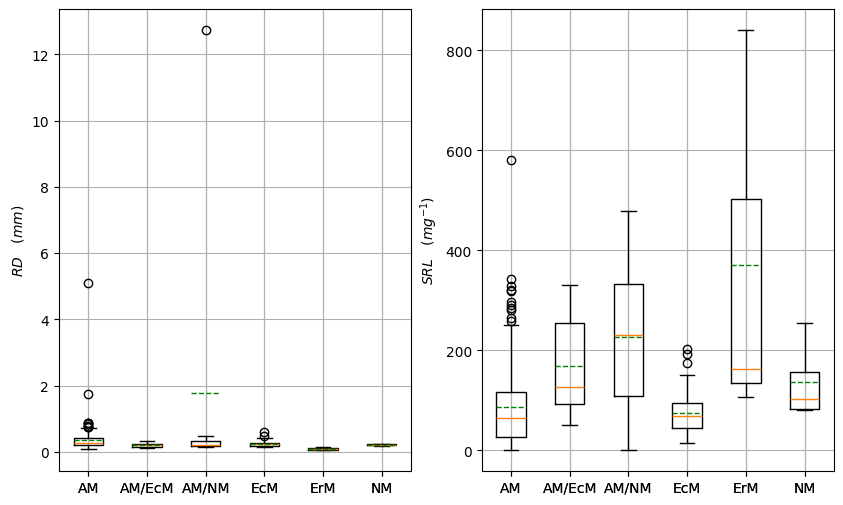

In [10]:
fig, (axes_0, axes_1) = plt.subplots(ncols=2, sharex=True)
fig.set_size_inches(10, 6)

# notice the very far off outliers in RD?????
axes_0.boxplot(x=[df.F00679 for (_, df) in merged395.groupby("state", as_index=True)], tick_labels=[_ for (_, df) in merged395.groupby("state", as_index=True)], showmeans=True, meanline=True, meanprops={"color": "green"})
axes_0.grid()
axes_0.set_axisbelow(True)
axes_0.set_ylabel(r"$RD\hspace{1}(mm)$")
# axes_0.set_ylim(0, 2)

axes_1.boxplot(x=[df.F00727 for (_, df) in merged395.groupby("state", as_index=True)], tick_labels=[_ for (_, df) in merged395.groupby("state", as_index=True)], showmeans=True, meanline=True, meanprops={"color": "green"})
axes_1.grid()
axes_1.set_axisbelow(True)
axes_1.set_ylabel(r"$SRL\hspace{1}(mg^{-1})$")

plt.show()

In [ ]:
# well, that sort of explains the hOUwie results

In [11]:
merged395.query(r"state=='NM'")

,binominal,F00679,F00727,state,reference
104,Cibotium barometz,0.248250,83.955135,NM,"['Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C,..."
146,Dryopteris lepidopoda,0.199867,122.611395,NM,"['Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C,..."
158,Equisetum pratense,0.243317,254.777067,NM,"['Akhmetzhanova AA, Soudzilovskaiana NA, Onipc..."
355,Schoepfia jasminodora,0.190950,81.482621,NM,"['Wang R, Wang Q, Zhao N, Xu Z, Zhu X, Jiao C,..."


In [12]:
merged395.query(r"F00679>=1.0") # potential outliers???

,binominal,F00679,F00727,state,reference
168,Fraxinus americana,1.761144,26.021329,AM,"[' Valverde-Barrantes OJ, Smemo KA, Blackwood ..."
184,Hydrophyllum canadense,12.730000,0.100000,AM/NM,FungalRoot
391,Viola pubescens,5.100000,0.500000,AM,FungalRoot


In [13]:
merged395.state.value_counts()

state
AM        300
EcM        65
AM/EcM     15
AM/NM       8
NM          4
ErM         3
Name: count, dtype: int64

## ___1mm RD cutoff subset___
-----------------------------------

In [5]:
# these are species averaged RD, SRL values for 1005 species where the RD is <= 1.000 mm and root order is 1 or unknown
collab_1005sp = pd.read_csv(r"../../data/chapter2/FREDv3subset/collab_rdlteq1_rd1ornan_RD_SRL_species_avgd.csv")
collab_1005sp.head()

,binominal,root_order,RD,SRL,references,genus,species,family,order
0,Abelia biflora,1.0,0.529200,30.947057,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Abelia,biflora,Caprifoliaceae,Dipsacales
1,Abies fargesii,1.0,0.274904,30.655175,"<ArrowStringArray>\n['Pu X, Yin C, Xioa Q, Qia...",Abies,fargesii,Pinaceae,Pinales
2,Abies nephrolepis,1.0,0.415233,27.045857,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Abies,nephrolepis,Pinaceae,Pinales
3,Acacia auriculiformis,1.0,0.334800,77.290000,"<ArrowStringArray>\n['Kong D, Ma C, Zhang Q, L...",Acacia,auriculiformis,Fabaceae,Fabales
4,Acacia crassicarpa,1.0,0.225930,108.280000,"<ArrowStringArray>\n['Kong D, Ma C, Zhang Q, L...",Acacia,crassicarpa,Fabaceae,Fabales


In [6]:
sum(collab_1005sp.RD > 1.000) # yup!

0

In [7]:
collab_1005sp.root_order.unique() # as expected

array([ 1., nan])

In [8]:
# let's use the genus level mycorrhizal state recommendations from FungalRoot for this
fungalroot_genus_level_recommendations = pd.read_excel(r"../../data/chapter2/FungalRoot/nph16569-sup-0002-tabless1-s4.xlsx", sheet_name="Table S2", skiprows=range(2))
fungalroot_genus_level_recommendations.rename({"Genus": "genus", "Mycorrhizal type": "state"}, axis=1, inplace=True)

In [9]:
fungalroot_genus_level_recommendations.head()

,genus,state
0,Aa,OM
1,Aaronsohnia,AM
2,Abarema,AM
3,Abatia,AM
4,Abdra,NM


In [10]:
fungalroot_genus_1005sp_merged = pd.merge(left=collab_1005sp, left_on="genus", right=fungalroot_genus_level_recommendations, right_on="genus", how="left")
fungalroot_genus_1005sp_merged.state.isna().sum()

np.int64(3)

In [11]:
fungalroot_genus_1005sp_merged.query(r"state.isna()")

,binominal,root_order,RD,SRL,references,genus,species,family,order,state
0,Abelia biflora,1.0,0.529200,30.947057,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Abelia,biflora,Caprifoliaceae,Dipsacales,NaN
605,Eurotia lanata,NaN,0.245475,79.606511,"<ArrowStringArray>\n['Kembel SW, Cahill JF, Jr...",Eurotia,lanata,Amaranthaceae,Caryophyllales,NaN
853,Pseudosclerochloa rupestris,NaN,0.164000,142.631810,"<ArrowStringArray>\n['Kembel SW, Cahill JF, Jr...",Pseudosclerochloa,rupestris,Poaceae,Poales,NaN


In [12]:
fungalroot_genus_1005sp_merged.query(r"state=='NM'").loc[:, ["genus", "species", "family", "order"]].drop_duplicates()

,genus,species,family,order
182,Helicia,formosana,Proteaceae,Proteales
410,Alliaria,petiolata,Brassicaceae,Brassicales
472,Berteroa,incana,Brassicaceae,Brassicales
574,Descurainia,sophia,Brassicaceae,Brassicales
580,Draba,nemorosa,Brassicaceae,Brassicales
602,Erysimum,inconspicuum,Brassicaceae,Brassicales
633,Hakea,ceratophylla,Proteaceae,Proteales
634,Hakea,cyclocarpa,Proteaceae,Proteales
635,Hakea,linearis,Proteaceae,Proteales
636,Hakea,lissocarpha,Proteaceae,Proteales


In [13]:
fungalroot_genus_level_recommendations.query(r"genus.isin(('Abelia', 'Eurotia', 'Pseudosclerochloa'))") # whoops

,genus,state


In [14]:
# can we find the states for the above genera from the species state FungalRoot dataset???
# https://en.wikipedia.org/wiki/Abelia
# Abelia tomentosa is used to be called Diabelia serrata, which we have the state info for in FungalRoot - AM
# https://en.wikipedia.org/wiki/Krascheninnikovia_lanata - other name for Eurotia lanata - AM (the alternative name has state info in the genus level recommendations dataset)
# https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:60434447-2 - says Pseudosclerochloa rupestris is synonym of Puccinellia rupestris, which again the FungalRoot genus level recommendations datset has the state
# information for

In [15]:
fungalroot_genus_level_recommendations.query(r"genus=='Krascheninnikovia'")

,genus,state
7167,Krascheninnikovia,AM


In [16]:
fungalroot_genus_level_recommendations.query(r"genus=='Puccinellia'")

,genus,state
11349,Puccinellia,NM-AM


In [17]:
fungalroot_genus_1005sp_merged.loc[fungalroot_genus_1005sp_merged.genus=="Abelia", "state"] = "AM"
fungalroot_genus_1005sp_merged.loc[fungalroot_genus_1005sp_merged.genus=="Eurotia", "state"] = "AM"
fungalroot_genus_1005sp_merged.loc[fungalroot_genus_1005sp_merged.genus=="Pseudosclerochloa", "state"] = "NM-AM"

In [18]:
fungalroot_genus_1005sp_merged.query(r"state.isna()") # good :)

,binominal,root_order,RD,SRL,references,genus,species,family,order,state


In [19]:
fungalroot_genus_1005sp_merged.state.value_counts()

state
AM                                             777
EcM                                            122
NM-AM                                           49
EcM-AM                                          24
NM                                              18
ErM                                             10
uncertain                                        2
species-specific: AM or rarely EcM-AM or AM      2
OM                                               1
Name: count, dtype: int64

In [22]:
# try and rectify the "uncertain" and "species-specific: AM or rarely EcM-AM or AM" encoded species
fungalroot_genus_1005sp_merged.query(r"state.isin(('uncertain', 'species-specific: AM or rarely EcM-AM or AM'))")

,binominal,root_order,RD,SRL,references,genus,species,family,order,state
154,Embelia vestita,1.0,0.20785,96.430364,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Embelia,vestita,Primulaceae,Ericales,uncertain
679,Helichrysum italicum,NaN,0.31635,18.387871,"<ArrowStringArray>\n['de la Riva, Navarro-Fern...",Helichrysum,italicum,Asteraceae,Asterales,species-specific: AM or rarely EcM-AM or AM
680,Helichrysum stoechas,NaN,0.49195,6.114891,"<ArrowStringArray>\n['de la Riva, Navarro-Fern...",Helichrysum,stoechas,Asteraceae,Asterales,species-specific: AM or rarely EcM-AM or AM
681,Heliopsis helianthoides,NaN,0.38000,64.000000,"<ArrowStringArray>\n['Craine JM, Froehle J, Ti...",Heliopsis,helianthoides,Asteraceae,Asterales,uncertain


In [20]:
# in the detailed species level FungalRot dataset there's a record for genus Embelia saying it is NM
# same for Heliopsis helianthoides
# for Helichrysum, there are records for AM, EcM and EcM-AM, let's set this to EcM-AM

fungalroot_genus_1005sp_merged.loc[fungalroot_genus_1005sp_merged.genus=="Embelia", "state"] = "NM"
fungalroot_genus_1005sp_merged.loc[fungalroot_genus_1005sp_merged.genus=="Heliopsis", "state"] = "NM"
fungalroot_genus_1005sp_merged.loc[fungalroot_genus_1005sp_merged.genus=="Helichrysum", "state"] = "EcM-AM"

In [21]:
fungalroot_genus_1005sp_merged.state.value_counts()

state
AM        777
EcM       122
NM-AM      49
EcM-AM     26
NM         20
ErM        10
OM          1
Name: count, dtype: int64

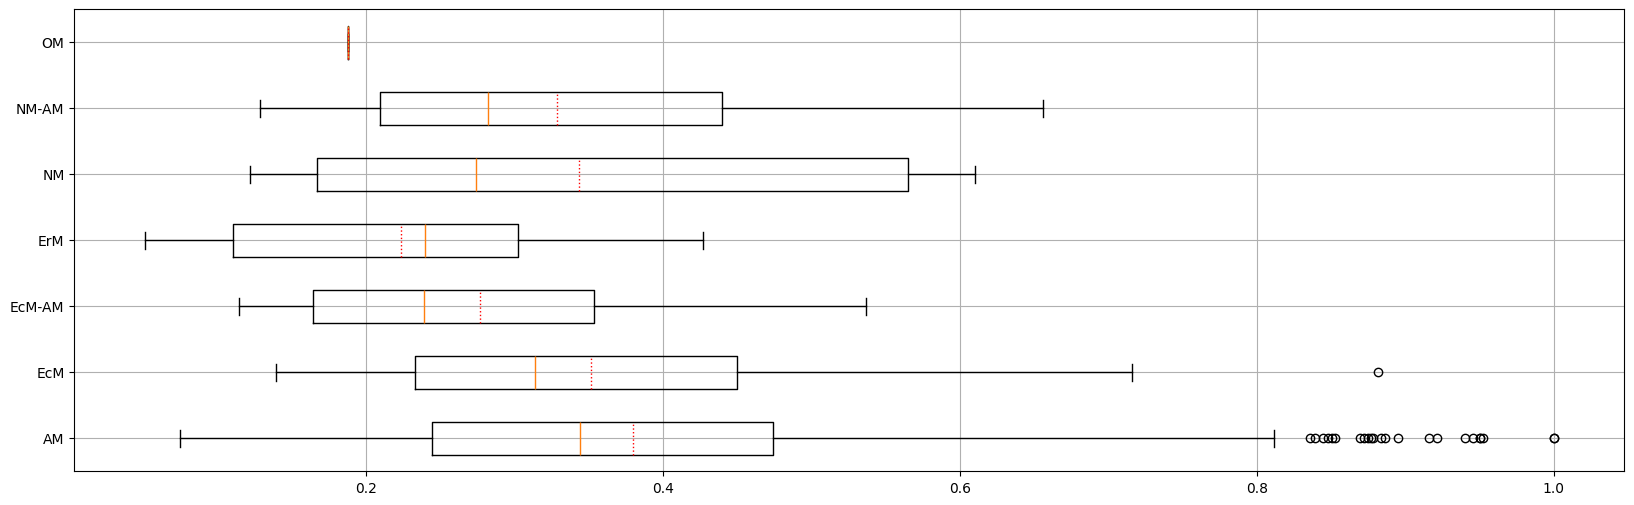

In [27]:
fig, axes = plt.subplots()
fig.set_size_inches(20, 6)
axes.boxplot([grp.RD for (state, grp) in fungalroot_genus_1005sp_merged.groupby("state")], tick_labels=[state for (state, grp) in fungalroot_genus_1005sp_merged.groupby("state")], showmeans=True, meanline=True,
            orientation="horizontal", meanprops={"color": "red", "linestyle": "dotted"})
axes.grid()
plt.show()

In [66]:
fungalroot_genus_1005sp_merged.head()

,binominal,F00056,F00679,F00727,F00004,F01286,F01287,F01289,F01290,genus,state
0,Abelia biflora,1.0,0.529200,30.947057,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Abelia,biflora,Caprifoliaceae,Dipsacales,NaN,AM
1,Abies fargesii,1.0,0.274904,30.655175,"<ArrowStringArray>\n['Pu X, Yin C, Xioa Q, Qia...",Abies,fargesii,Pinaceae,Pinales,Abies,EcM
2,Abies nephrolepis,1.0,0.415233,27.045857,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Abies,nephrolepis,Pinaceae,Pinales,Abies,EcM
3,Acacia auriculiformis,1.0,0.334800,77.290000,"<ArrowStringArray>\n['Kong D, Ma C, Zhang Q, L...",Acacia,auriculiformis,Fabaceae,Fabales,Acacia,EcM-AM
4,Acacia crassicarpa,1.0,0.225930,108.280000,"<ArrowStringArray>\n['Kong D, Ma C, Zhang Q, L...",Acacia,crassicarpa,Fabaceae,Fabales,Acacia,EcM-AM


In [23]:
# prepare this dataset for OUwie fits
fungalroot_genus_1005sp_merged.loc[:, "binominal"] = fungalroot_genus_1005sp_merged.binominal.str.replace(' ', '_')
fungalroot_genus_1005sp_merged.loc[:, "state"] = fungalroot_genus_1005sp_merged.state.str.replace('-', '')

In [24]:
fungalroot_genus_1005sp_merged

,binominal,root_order,RD,SRL,references,genus,species,family,order,state
0,Abelia_biflora,1.0,0.529200,30.947057,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Abelia,biflora,Caprifoliaceae,Dipsacales,AM
1,Abies_fargesii,1.0,0.274904,30.655175,"<ArrowStringArray>\n['Pu X, Yin C, Xioa Q, Qia...",Abies,fargesii,Pinaceae,Pinales,EcM
2,Abies_nephrolepis,1.0,0.415233,27.045857,"<ArrowStringArray>\n['Wang R, Wang Q, Zhao N, ...",Abies,nephrolepis,Pinaceae,Pinales,EcM
3,Acacia_auriculiformis,1.0,0.334800,77.290000,"<ArrowStringArray>\n['Kong D, Ma C, Zhang Q, L...",Acacia,auriculiformis,Fabaceae,Fabales,EcMAM
4,Acacia_crassicarpa,1.0,0.225930,108.280000,"<ArrowStringArray>\n['Kong D, Ma C, Zhang Q, L...",Acacia,crassicarpa,Fabaceae,Fabales,EcMAM
...,...,...,...,...,...,...,...,...,...,...
1000,Weinmannia_racemosa,NaN,0.378571,54.950961,"<ArrowStringArray>\n['Kramer-Walter KR, Bellin...",Weinmannia,racemosa,Cunoniaceae,Oxalidales,AM
1001,Weinmannia_silvicola,NaN,0.383120,44.072685,"<ArrowStringArray>\n['Kramer-Walter KR, Bellin...",Weinmannia,silvicola,Cunoniaceae,Oxalidales,AM
1002,Withania_frutescens,NaN,0.391800,5.831897,"<ArrowStringArray>\n['de la Riva, Navarro-Fern...",Withania,frutescens,Solanaceae,Solanales,AM
1003,Xanthophyllum_tenue,NaN,0.435750,25.229250,"<ArrowStringArray>\n['Ushio M, Fujiki Y, Hidak...",Xanthophyllum,tenue,Polygalaceae,Fabales,AM


In [36]:
# serialize this for OUwie::hUOwie fits.
# column order - binominal name, discrete trait followed by continuous trait

# HERE WE HAVE THE CONTINUOUS TRAIT LOG TRANSFORMED
rd = fungalroot_genus_1005sp_merged.loc[:, ["binominal", "state", "RD"]]
rd.loc[:, "RD"] = np.log(rd.RD)
srl = fungalroot_genus_1005sp_merged.loc[:, ["binominal", "state", "SRL"]]
srl.loc[:, "SRL"] = np.log(srl.SRL)

# serialize them
rd.to_csv(r"../../R/parhOUwie/genus_state_rec_logged_species_avgd_RD_1005sp.csv", index=False)
srl.to_csv(r"../../R/parhOUwie/genus_state_rec_logged_species_avgd_SRL_1005sp.csv", index=False)

In [26]:
# state augmentations
fungalroot_genus_1005sp_merged.state.unique()

<ArrowStringArray>
['AM', 'EcM', 'EcMAM', 'NMAM', 'NM', 'ErM', 'OM']
Length: 7, dtype: str